# Decision Tree - Predict Brease Cancer


## Problem Understanding
* What factors contribute to breast cancer?
* What does a predictive model look like? 

In [1]:
# --- Import Libraries ---
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

from sklearn.tree import DecisionTreeClassifier, export_graphviz

### Put the data in to a DataFrame

In [2]:
# -- Load the dataset
cancer = pd.read_csv("https://raw.githubusercontent.com/ttchuang/dataset/master/breast_cancer_short.csv")

In [3]:
# -- properties of data --
cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   radius_mean             424 non-null    float64
 1   texture_mean            424 non-null    float64
 2   perimeter_mean          424 non-null    float64
 3   area_mean               424 non-null    float64
 4   smoothness_mean         424 non-null    float64
 5   compactness_mean        424 non-null    float64
 6   concavity_mean          424 non-null    float64
 7   concave points_mean     424 non-null    float64
 8   symmetry_mean           424 non-null    float64
 9   fractal_dimension_mean  424 non-null    float64
 10  diagnosis               424 non-null    object 
dtypes: float64(10), object(1)
memory usage: 36.6+ KB


In [4]:
# -- preview the data --
cancer.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,diagnosis
0,28.11,18.47,188.50,2499.0,0.11420,0.15160,0.320100,0.15950,0.1648,0.05525,M
1,15.06,19.83,100.30,705.6,0.10390,0.15530,0.170000,0.08815,0.1855,0.06284,M
2,14.44,15.18,93.97,640.1,0.09970,0.10210,0.084870,0.05532,0.1724,0.06081,B
3,20.59,21.24,137.80,1320.0,0.10850,0.16440,0.218800,0.11210,0.1848,0.06222,M
4,12.81,13.06,81.29,508.8,0.08739,0.03774,0.009193,0.01330,0.1466,0.06133,B


In [5]:
# -- add labels of diagonsis to the dataframe --
# -- M: Malignant --
# -- B: Benign --
cancer['outcome'] = cancer['diagnosis'].apply(lambda x: 'Benign' if(x=='B') else 'Malignant')
cancer['diagnosis'] = cancer['diagnosis'].apply(lambda x: 0 if(x=='B') else 1)

In [6]:
# -- Dataframe shape --
cancer.shape

(424, 12)

In [10]:
# -- Preview the data --

cancer.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,diagnosis,outcome
0,28.11,18.47,188.50,2499.0,0.11420,0.15160,0.320100,0.15950,0.1648,0.05525,1,Malignant
1,15.06,19.83,100.30,705.6,0.10390,0.15530,0.170000,0.08815,0.1855,0.06284,1,Malignant
2,14.44,15.18,93.97,640.1,0.09970,0.10210,0.084870,0.05532,0.1724,0.06081,0,Benign
3,20.59,21.24,137.80,1320.0,0.10850,0.16440,0.218800,0.11210,0.1848,0.06222,1,Malignant
4,12.81,13.06,81.29,508.8,0.08739,0.03774,0.009193,0.01330,0.1466,0.06133,0,Benign


### Examine relationships between features

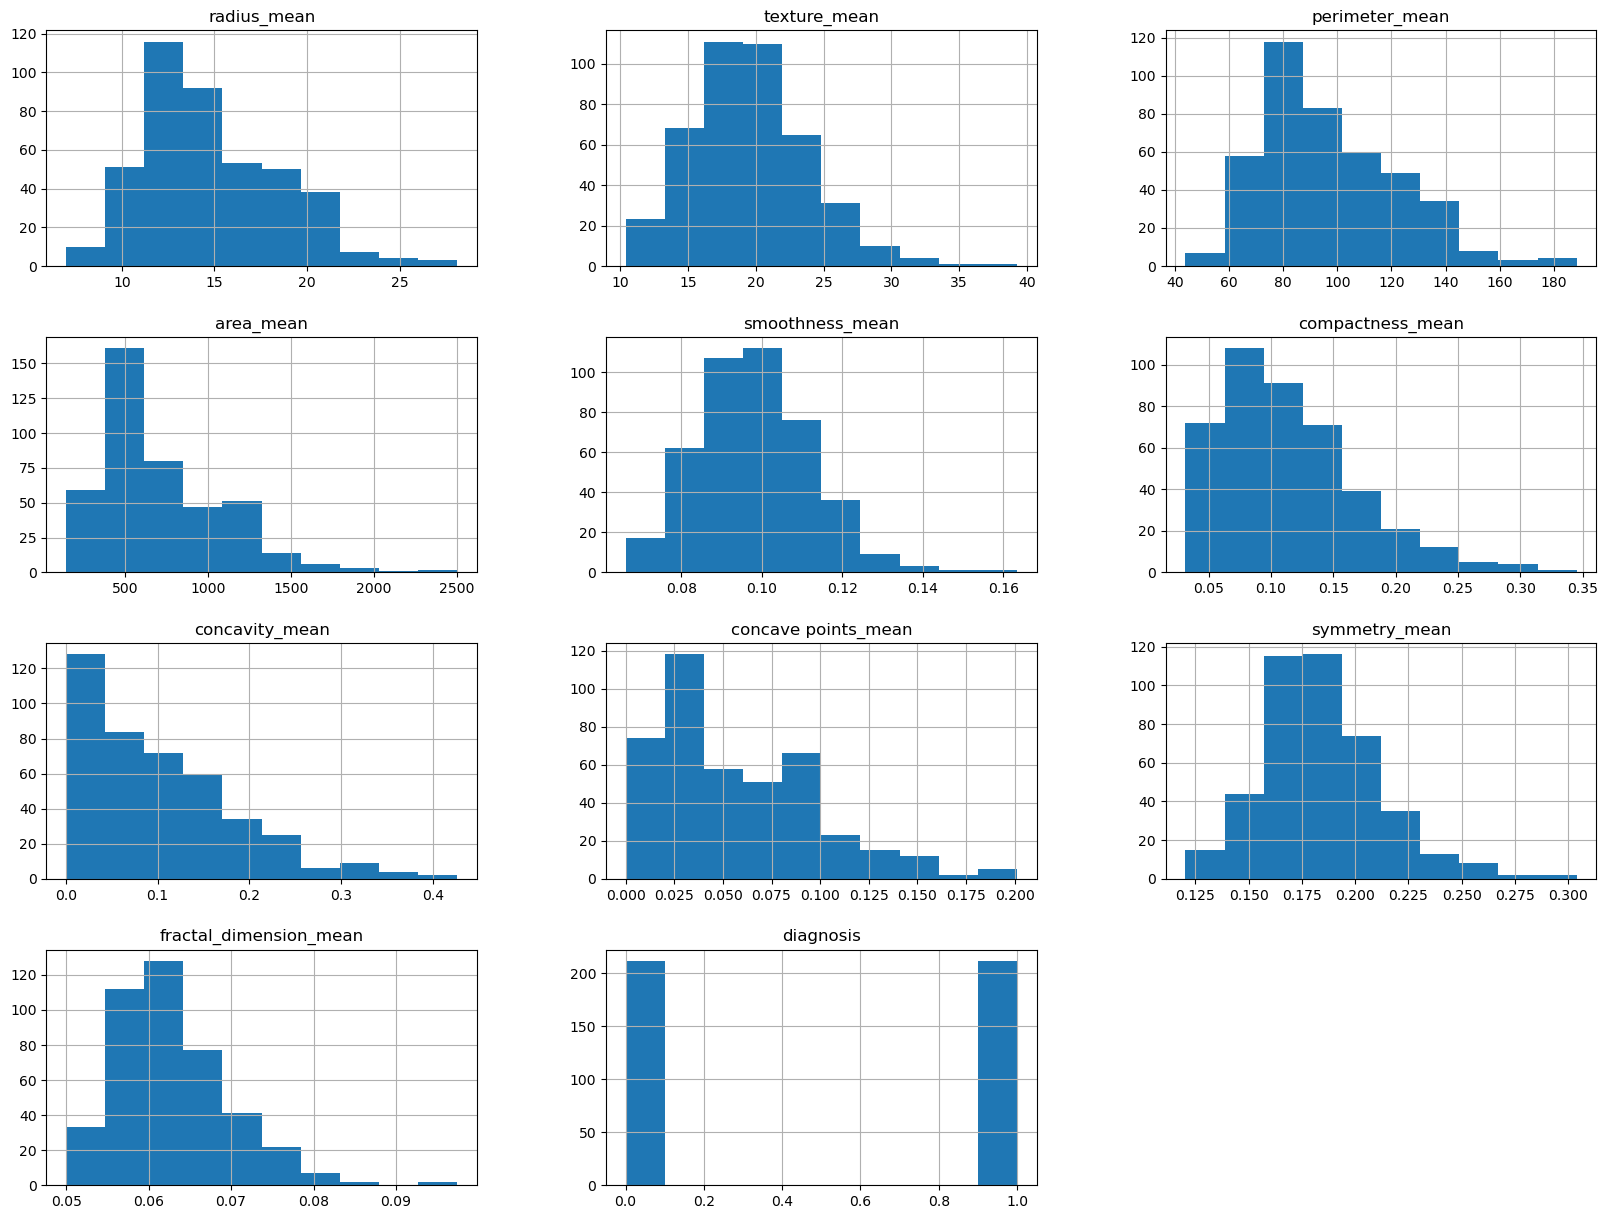

In [7]:
# -- Examine the distributin of variables --
cancer.iloc[:,:-1].hist(bins=10,figsize=(20,15))
plt.show();

In [9]:
# -- find correlations between features --
cancer.iloc[:,:-1].corr()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,diagnosis
radius_mean,1.000000,0.385897,0.997733,0.988219,0.131510,0.495973,0.689140,0.830198,0.150663,-0.325430,0.717330
texture_mean,0.385897,1.000000,0.393043,0.370246,0.007567,0.296139,0.363789,0.357274,0.095116,-0.073040,0.472046
perimeter_mean,0.997733,0.393043,1.000000,0.986808,0.169329,0.548529,0.729674,0.858699,0.187649,-0.273141,0.728536
area_mean,0.988219,0.370246,0.986808,1.000000,0.139077,0.481219,0.689849,0.823869,0.144231,-0.304470,0.682114
smoothness_mean,0.131510,0.007567,0.169329,0.139077,1.000000,0.636592,0.517927,0.529595,0.566104,0.609526,0.324815
compactness_mean,0.495973,0.296139,0.548529,0.481219,0.636592,1.000000,0.888084,0.820963,0.616900,0.569711,0.574873
concavity_mean,0.689140,0.363789,0.729674,0.689849,0.517927,0.888084,1.000000,0.926525,0.506031,0.319632,0.680910
concave points_mean,0.830198,0.357274,0.858699,0.823869,0.529595,0.820963,0.926525,1.000000,0.464202,0.146462,0.755234
symmetry_mean,0.150663,0.095116,0.187649,0.144231,0.566104,0.616900,0.506031,0.464202,1.000000,0.483975,0.320604
fractal_dimension_mean,-0.325430,-0.073040,-0.273141,-0.304470,0.609526,0.569711,0.319632,0.146462,0.483975,1.000000,-0.035782


In [10]:
# -- find correlations between features --
mx = cancer.iloc[:,:-1].corr()
mx

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,diagnosis
radius_mean,1.000000,0.385897,0.997733,0.988219,0.131510,0.495973,0.689140,0.830198,0.150663,-0.325430,0.717330
texture_mean,0.385897,1.000000,0.393043,0.370246,0.007567,0.296139,0.363789,0.357274,0.095116,-0.073040,0.472046
perimeter_mean,0.997733,0.393043,1.000000,0.986808,0.169329,0.548529,0.729674,0.858699,0.187649,-0.273141,0.728536
area_mean,0.988219,0.370246,0.986808,1.000000,0.139077,0.481219,0.689849,0.823869,0.144231,-0.304470,0.682114
smoothness_mean,0.131510,0.007567,0.169329,0.139077,1.000000,0.636592,0.517927,0.529595,0.566104,0.609526,0.324815
compactness_mean,0.495973,0.296139,0.548529,0.481219,0.636592,1.000000,0.888084,0.820963,0.616900,0.569711,0.574873
concavity_mean,0.689140,0.363789,0.729674,0.689849,0.517927,0.888084,1.000000,0.926525,0.506031,0.319632,0.680910
concave points_mean,0.830198,0.357274,0.858699,0.823869,0.529595,0.820963,0.926525,1.000000,0.464202,0.146462,0.755234
symmetry_mean,0.150663,0.095116,0.187649,0.144231,0.566104,0.616900,0.506031,0.464202,1.000000,0.483975,0.320604
fractal_dimension_mean,-0.325430,-0.073040,-0.273141,-0.304470,0.609526,0.569711,0.319632,0.146462,0.483975,1.000000,-0.035782


In [11]:
# -- retrieve columns whose coefficients with 'diagnosis' > 0.7
cols = list(mx['diagnosis'][mx['diagnosis']>0.7][:3].index)
cols

['radius_mean', 'perimeter_mean', 'concave points_mean']

In [12]:
# -- retrieve columns whose coefficients with 'diagnosis' > 0.7
mx['diagnosis'][mx['diagnosis']>0.7][:3]


radius_mean            0.717330
perimeter_mean         0.728536
concave points_mean    0.755234
Name: diagnosis, dtype: float64

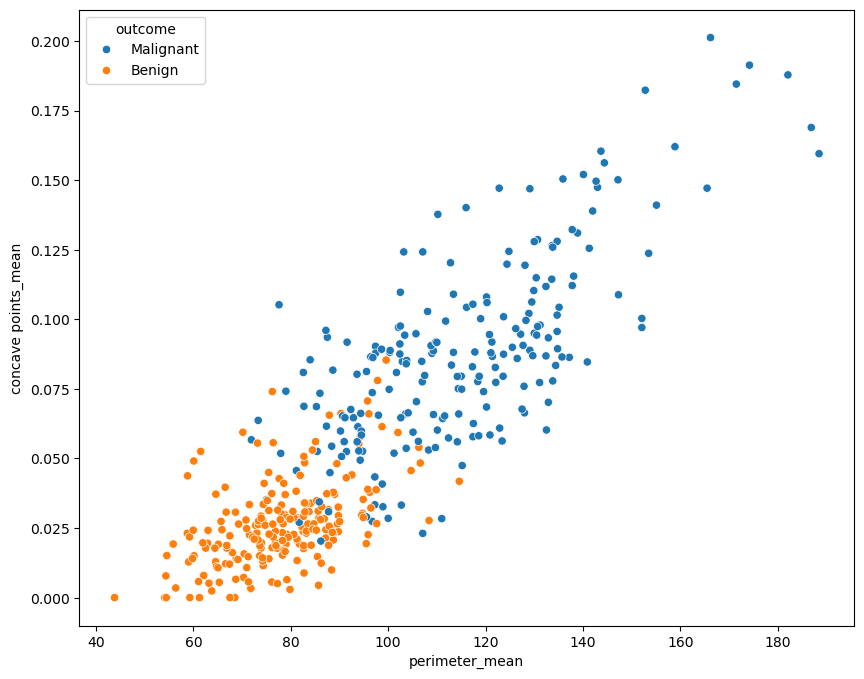

In [13]:
# -- Use DataFrame and Seaborn --

%matplotlib inline

plt.figure(figsize=(10,8)) # -- Here figsize(,) is a function to determine the size (inch) of the figure (canvas) 
sns.scatterplot(x=cancer['perimeter_mean'],
                y=cancer['concave points_mean'],
                hue=cancer['outcome'])
plt.show();
# -- the parameter, hue, in seaborn works like a legend --

# Modeling


## Train the Model


In [14]:
# -- preview the dataset --
cancer[cols]

,radius_mean,perimeter_mean,concave points_mean
0,28.110,188.50,0.15950
1,15.060,100.30,0.08815
2,14.440,93.97,0.05532
3,20.590,137.80,0.11210
4,12.810,81.29,0.01330
...,...,...,...
419,9.042,60.07,0.04908
420,14.480,94.25,0.04938
421,8.571,54.53,0.01510
422,11.850,75.54,0.02280


In [15]:
# -- Extract features --
X = cancer[cols]
y = cancer['diagnosis']

## Split data into train and testing

In [16]:
# --- Split data into training and testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.25,
                                                    random_state = 1,
                                                    stratify = y)
X_train.head()

,radius_mean,perimeter_mean,concave points_mean
313,19.53,129.50,0.10620
189,20.09,134.70,0.12800
282,17.91,124.40,0.11980
354,17.68,117.40,0.10540
379,11.80,78.99,0.07415


## Fit the model 

In [17]:
# -- Run the CART model --
# cart_adult = DecisionTreeClassifier(criterion = 'gini',max_leaf_nodes = 5).fit(X,y)
dt_clf = DecisionTreeClassifier(criterion = 'gini',
                                max_leaf_nodes = 5)
dt_clf.fit(X_train,y_train)

DecisionTreeClassifier(max_leaf_nodes=5)

## Visualize the Tree


In [18]:
# -- Extract labels --
y_names = ['Benign','Malignant']

In [19]:
# -- Feature names --
X.columns

Index(['radius_mean', 'perimeter_mean', 'concave points_mean'], dtype='object')

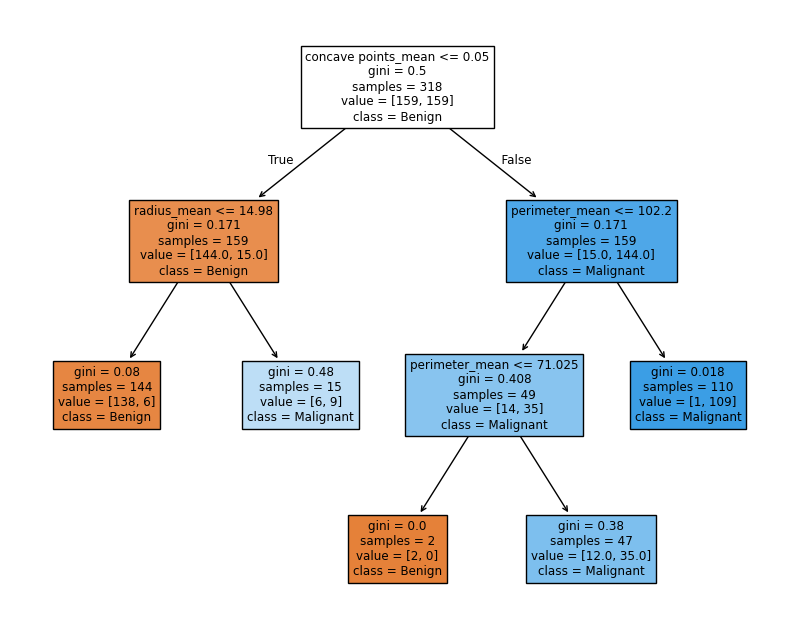

In [20]:
# -- Plot the decision tree --

from sklearn import tree

plt.figure(figsize=(10,8))

_ = tree.plot_tree(dt_clf,
                   feature_names = X.columns,
                   class_names = y_names,
                   filled = True)
plt.show();

# Model Performance Evaluation
## Confusion Matrix - Training Data

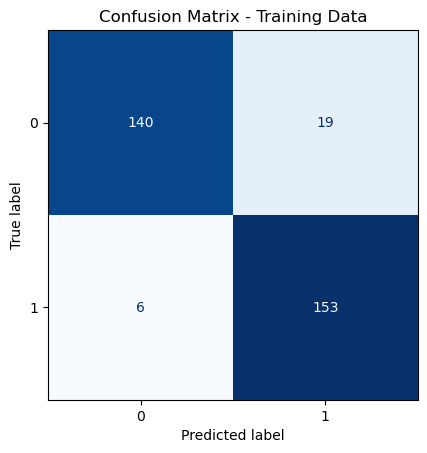

In [21]:
# -- Confusion Matrix - Training Data --

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(dt_clf,
                                      X_train,
                                      y_train,
                                      cmap="Blues",
                                      colorbar=False,
                                      display_labels=dt_clf.classes_)
plt.title("Confusion Matrix - Training Data")
plt.show();

## Accuracy, Recall, Precision, and Other metrics

In [22]:
# -- Accuracy: num of correct predictions divided by the total of predictions

print('--- Accuracy ---')
print(dt_clf.score(X = X_train, y = y_train))

--- Accuracy ---
0.9213836477987422


In [23]:
# -- View summary of common classification metrics
preds = dt_clf.predict(X_train)
print('--- Metrices ---')
print(metrics.classification_report(y_true = y_train, y_pred = preds))

--- Metrices ---
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       159
           1       0.89      0.96      0.92       159

    accuracy                           0.92       318
   macro avg       0.92      0.92      0.92       318
weighted avg       0.92      0.92      0.92       318



## Receiver Operating Characteristic (ROC) Curve
**Note:** 
* The ROC curve is created by plotting the TPR against the FPR at various thrshold settings. 
* Threshold of 0.5: all of those predicted probabilities less than or equal to 0.5 belong to one class, while those greater than 0.5 belong to another class.

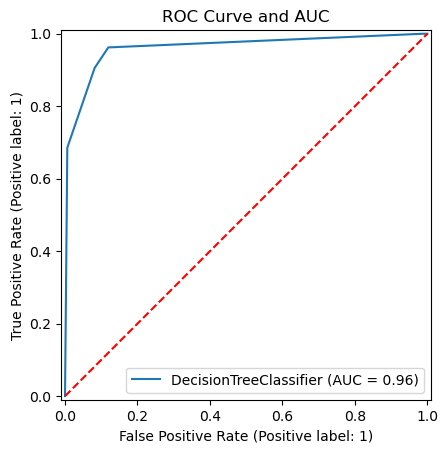

In [24]:
# -- plot the ROC curve using RocCurveDisplay --
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(dt_clf, 
                               X_train,
                               y_train)
plt.plot([0,1],[0,1],'r--')
plt.title('ROC Curve and AUC')
plt.show();

## Confusion Matrix - Testing Data

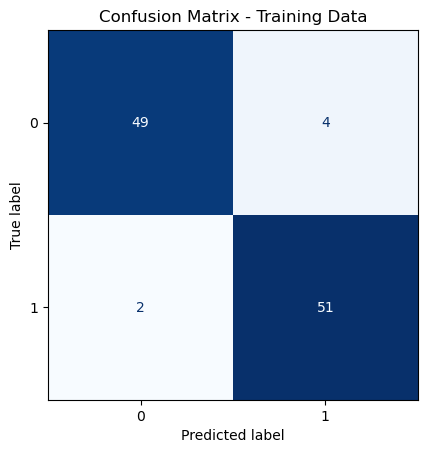

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds_test = dt_clf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test,
                                      preds_test,
                                      cmap="Blues",
                                      colorbar=False,
                                      display_labels=dt_clf.classes_)
plt.title("Confusion Matrix - Training Data")
plt.show();

## Accuracy, Recall, Precision, and Other Metrics

In [26]:
# -- Accuracy: num of correct predictions divided by the total of predictions

print('--- Accuracy ---')
print(dt_clf.score(X = X_test, y = y_test))

--- Accuracy ---
0.9433962264150944


In [27]:
# -- View summary of common classification metrics
preds_test = dt_clf.predict(X_test)
print('--- Metrices ---')
print(metrics.classification_report(y_true = y_test, y_pred = preds_test))

--- Metrices ---
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.93      0.96      0.94        53

    accuracy                           0.94       106
   macro avg       0.94      0.94      0.94       106
weighted avg       0.94      0.94      0.94       106



## Receiver Operating Characteristic (ROC) Curve
**Note:** 
* The ROC curve is created by plotting the TPR against the FPR at various thrshold settings. 
* Threshold of 0.5: all of those predicted probabilities less than or equal to 0.5 belong to one class, while those greater than 0.5 belong to another class.

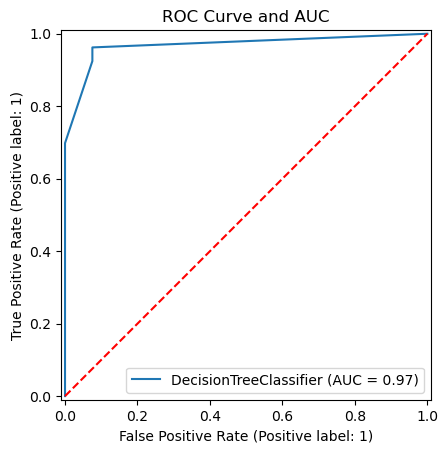

In [28]:
# -- plot the ROC curve using RocCurveDisplay --
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(dt_clf, 
                               X_test,
                               y_test)
plt.plot([0,1],[0,1],'r--')
plt.title('ROC Curve and AUC')
plt.show();

## Comparison between predicted diagnosis and actual diagnosis

In [29]:
# --- Get the predicted class labels ---
preds = dt_clf.predict(X = X_test)
preds_class = pd.DataFrame(preds)
preds_class.columns = ['Prediction']

# -- Get the probability --
preds_prob = dt_clf.predict_proba(X = X_test)
preds_prob = pd.DataFrame(preds_prob,
                         columns = ['Benign','Maligant'])

# --- Actual diagnosis ---
original_result = pd.DataFrame(y_test.values)
original_result.columns = ['Original Result']

# --- Merge the three dataframes together ---
# -- 0: Malignant 
# -- 1: Benign
result = pd.concat([preds_prob, preds_class, original_result], axis = 1)
result.head()

,Benign,Maligant,Prediction,Original Result
0,0.958333,0.041667,0,0
1,0.958333,0.041667,0,0
2,0.255319,0.744681,1,1
3,0.255319,0.744681,1,1
4,0.958333,0.041667,0,1
